In [5]:
!pip install opencv-python opencv-contrib-python matplotlib numpy

Görüntü boyutu: (400, 700)
Gri seviye aralığı: [13, 251]


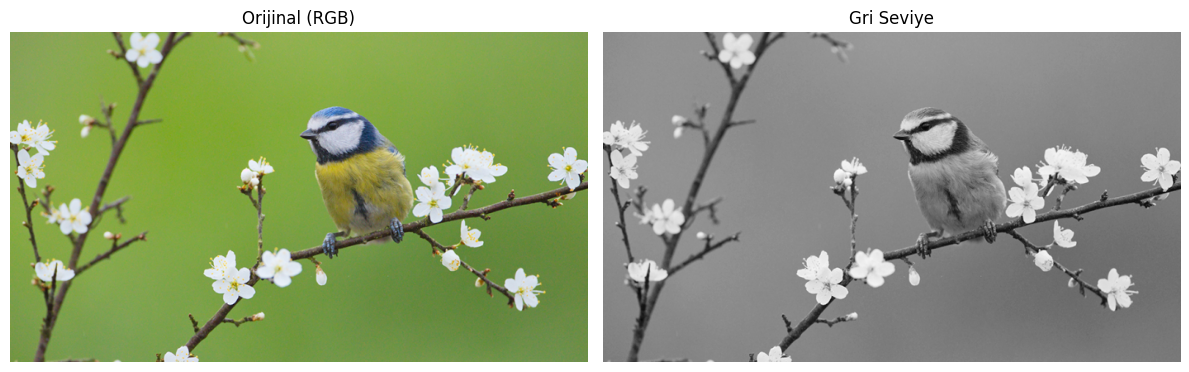

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files
import urllib.request

# Örnek bir masaüstü görüntüsü indir (kendi görüntülerinizi de yükleyebilirsiniz)
#url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
#urllib.request.urlretrieve(url, "sample.jpg")

# Alternatif: Kendi görüntünüzü yükleyin
url = "https://raw.githubusercontent.com/DemirMesutOztas/Robotik-Goruntu-Isleme-ve-Nesne-Tanima-icin-Parametre-Analizi/70d080fb50dfbb689e86eca8535a601a21b64c4a/rengarenk-bir-kus-turu-mavi-bastankara.jpg"
urllib.request.urlretrieve(url, "sample.jpg")
#uploaded = files.upload()
#img_path = list(uploaded.keys())[0]

img_path = "sample.jpg"
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Görüntü boyutu: {img_gray.shape}")
print(f"Gri seviye aralığı: [{img_gray.min()}, {img_gray.max()}]")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Orijinal (RGB)")
axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Gri Seviye")
axes[1].axis('off')
plt.tight_layout()
plt.show()

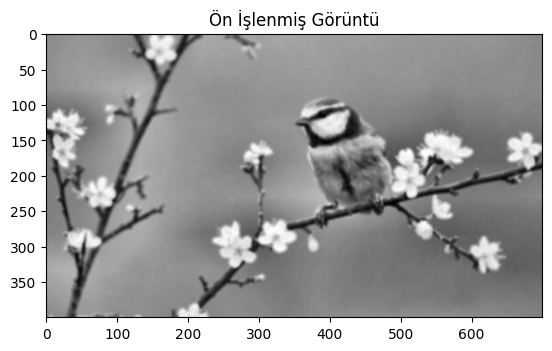

In [7]:
def preprocess_image(img_gray, gaussian_sigma=1.5, clahe_clip=2.0, clahe_grid=8):
    """
    Görüntü ön işleme hattı.

    Args:
        img_gray      : Gri seviye görüntü (H × W)
        gaussian_sigma: Gauss filtresi standart sapması
        clahe_clip    : CLAHE kırpma limiti
        clahe_grid    : CLAHE karo boyutu (grid × grid)

    Returns:
        img_processed : İşlenmiş gri seviye görüntü
    """
    img_smooth = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=gaussian_sigma)
    # Adım 1: Gauss yumuşatma (Gaussian smoothing) — gürültü azaltma
    # TODO: cv2.GaussianBlur kullanarak img_gray'e Gauss filtresi uygulayın
    # İpucu: Kernel boyutunu (0, 0) verirseniz, sigma'dan otomatik hesaplanır


    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(clahe_grid, clahe_grid))
    img_clahe = clahe.apply(img_smooth)

    # Adım 2: CLAHE ile kontrast iyileştirme (contrast enhancement)
    # TODO: cv2.createCLAHE ile CLAHE nesnesi oluşturun, apply ile uygulayın


    return img_clahe


img_processed = preprocess_image(img_gray)
plt.imshow(img_processed, cmap='gray')
plt.title("Ön İşlenmiş Görüntü")
plt.show()

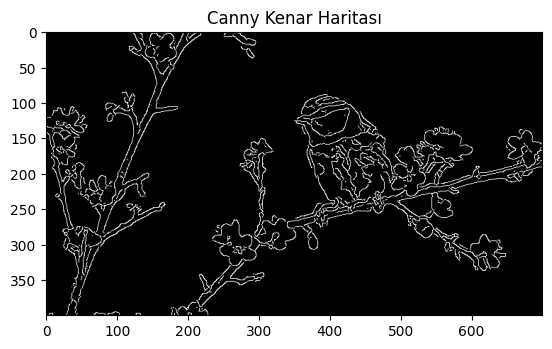

Bulunan kontur sayısı: 413


In [8]:
def detect_edges_and_contours(img_processed, canny_low=30, canny_high=90):
    """
    Canny kenar tespiti ve kontur bulma.

    Args:
        img_processed : Ön işlenmiş gri seviye görüntü
        canny_low     : Canny düşük eşik değeri
        canny_high    : Canny yüksek eşik değeri

    Returns:
        edges         : Canny kenar haritası (ikili)
        contours      : Bulunan konturların listesi
    """
    # Adım 1: Canny kenar tespiti
    # TODO: cv2.Canny kullanarak kenar haritasını oluşturun
    edges = cv2.Canny(img_processed, canny_low, canny_high)

    # Adım 2: Kontur bulma
    # TODO: cv2.findContours kullanarak konturları bulun
    # İpucu: cv2.RETR_EXTERNAL ve cv2.CHAIN_APPROX_SIMPLE kullanın
    #contours = None  # <-- TODO: Burayı doldurun (cv2.findContours iki değer döner)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    return edges, contours

# Test et
edges, contours = detect_edges_and_contours(img_processed)
plt.imshow(edges, cmap='gray')
plt.title("Canny Kenar Haritası")
plt.show()
print(f"Bulunan kontur sayısı: {len(contours)}")

In [9]:
def analyze_contours(contours, min_area=10, max_area=50000): #500-50000
    """
    Konturları analiz et, filtrele ve özelliklerini çıkar.

    Args:
        contours : Kontur listesi
        min_area : Minimum kontur alanı (küçük gürültüleri elemek için)
        max_area : Maksimum kontur alanı (arka planı elemek için)

    Returns:
        valid_contours : Filtrelenmiş kontur listesi
        contour_data   : Her kontur için (alan, çevre, dairesellik, ağırlık merkezi) listesi
    """
    valid_contours = []
    contour_data = []

    for cnt in contours:
        # TODO: cv2.contourArea ile kontur alanını hesaplayın
        area = cv2.contourArea(cnt)

        # Alan filtresi
        if area < min_area or area > max_area:
            continue

        # TODO: cv2.arcLength ile kontur çevresini hesaplayın
        perimeter = cv2.arcLength(cnt, True)

        # TODO: Dairesellik hesaplayın: 4π × alan / çevre²
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

        # TODO: cv2.moments ile ağırlık merkezini (centroid) hesaplayın
        M = cv2.moments(cnt)  # <-- TODO
        if M['m00'] != 0:
            cx =  int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0

        valid_contours.append(cnt)
        contour_data.append({
            'area': area,
            'perimeter': perimeter,
            'circularity': circularity,
            'centroid': (cx, cy)
        })

    return valid_contours, contour_data

# Test et
valid_cnt, cnt_data = analyze_contours(contours)
print(f"Filtrelenmiş kontur sayısı: {len(valid_cnt)}")

Filtrelenmiş kontur sayısı: 65


Bulunan ORB anahtar noktası: 300


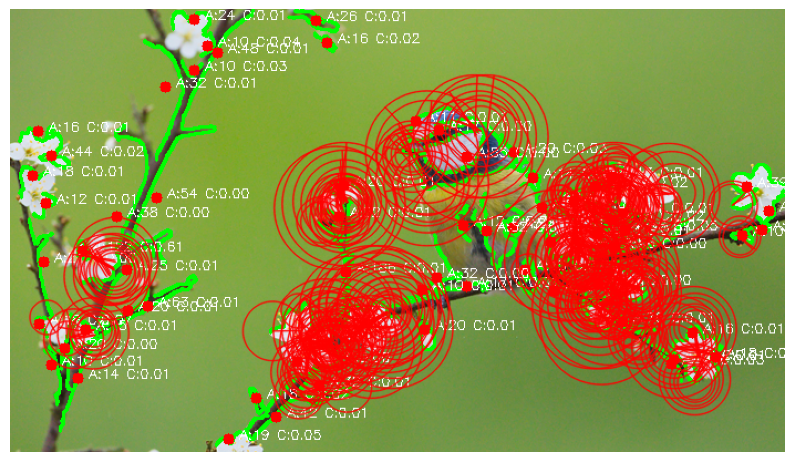

In [14]:

def extract_orb_features(img_gray, mask=None, n_features=300):
    """
    ORB öznitelik çıkarma.

    Args:
        img_gray   : Gri seviye görüntü
        mask       : İlgi bölgesi maskesi (isteğe bağlı)
        n_features : Maksimum öznitelik sayısı

    Returns:
        keypoints  : ORB anahtar noktaları
        descriptors: ORB betimleyicileri
    """
    # TODO: cv2.ORB_create ile ORB detektörü oluşturun (nfeatures parametresini kullanın)
    orb = cv2.ORB_create(nfeatures=n_features)

    # TODO: detectAndCompute ile anahtar noktaları ve betimleyicileri çıkarın
    keypoints, descriptors = orb.detectAndCompute(img_gray, mask)

    return keypoints, descriptors

def draw_results(img_rgb, valid_contours, contour_data, keypoints):
    """
    Sonuçları görselleştir.
    """
    img_result = img_rgb.copy()

    # Konturları çiz (yeşil)
    cv2.drawContours(img_result, valid_contours, -1, (0, 255, 0), 2)

    # Ağırlık merkezlerini ve bilgileri yaz
    for i, data in enumerate(contour_data):
        cx, cy = data['centroid']
        cv2.circle(img_result, (cx, cy), 5, (255, 0, 0), -1)
        cv2.putText(img_result, f"A:{data['area']:.0f} C:{data['circularity']:.2f}",
                    (cx+10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    # ORB anahtar noktalarını çiz (kırmızı)
    img_result = cv2.drawKeypoints(img_result, keypoints, None,
                                   color=(255, 0, 0),
                                   flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    return img_result

# Test et (TODO'lar doldurulduktan sonra)
keypoints, descriptors = extract_orb_features(img_gray)
print(f"Bulunan ORB anahtar noktası: {len(keypoints)}")
img_final = draw_results(img_rgb, valid_cnt, cnt_data, keypoints)
plt.figure(figsize=(10, 10))
plt.imshow(img_final)
plt.axis('off')
plt.show()

In [15]:
def full_pipeline(img_path, config):
    """
    Tam görüntü işleme hattı.

    Args:
        img_path : Görüntü dosya yolu
        config   : Parametre sözlüğü

    Returns:
        results  : Sonuç metrikleri sözlüğü
        img_final: Sonuç görseli
    """
    # Görüntü yükleme
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Ön işleme
    img_processed = preprocess_image(
        img_gray,
        gaussian_sigma=config.get('gaussian_sigma', 1.5),
        clahe_clip=config.get('clahe_clip', 2.0),
        clahe_grid=config.get('clahe_grid', 8)
    )

    # Kenar tespiti ve kontur
    edges, contours = detect_edges_and_contours(
        img_processed,
        canny_low=config.get('canny_low', 30),
        canny_high=config.get('canny_high', 90)
    )

    # Kontur analizi
    valid_cnt, cnt_data = analyze_contours(
        contours,
        min_area=config.get('min_area', 10),
        max_area=config.get('max_area', 50000)
    )

    # ORB öznitelik
    keypoints, descriptors = extract_orb_features(
        img_gray,
        n_features=config.get('n_features', 300)
    )

    # Görselleştirme
    img_final = draw_results(img_rgb, valid_cnt, cnt_data, keypoints)

    # Metrikler
    results = {
        'num_contours_total': len(contours),
        'num_contours_valid': len(valid_cnt),
        'num_keypoints': len(keypoints),
        'avg_circularity': np.mean([d['circularity'] for d in cnt_data]) if cnt_data else 0,
        'avg_area': np.mean([d['area'] for d in cnt_data]) if cnt_data else 0
    }

    return results, img_final, edges

# Test (TODO'lar doldurulunca)
config_default = {
     'gaussian_sigma': 1.5,
     'clahe_clip': 2.0,
     'clahe_grid': 8,
     'canny_low': 30,
     'canny_high': 90,
     'min_area': 10,
     'max_area': 50000,
     'n_features': 300
 }
results, img_final, edges = full_pipeline(img_path, config_default)
print("Sonuçlar:", results)

Sonuçlar: {'num_contours_total': 413, 'num_contours_valid': 65, 'num_keypoints': 300, 'avg_circularity': np.float64(0.03412858061135753), 'avg_area': np.float64(32.292307692307695)}


In [16]:
#Deney configürasyonları
configs = {
    "Deney 1": {
        'gaussian_sigma': 1.5,
        'clahe_clip': 2.0, 'clahe_grid': 8,
        'canny_low': 50, 'canny_high': 150,
        'min_area': 10, 'max_area': 50000,
        'n_features': 300
    },
    "Deney 2": {
        'gaussian_sigma': 1.5,
        'clahe_clip': 2.0, 'clahe_grid': 8,
        'canny_low': 30, 'canny_high': 90,
        'min_area': 10, 'max_area': 50000,
        'n_features': 300
    },
    "Deney 3": {
        'gaussian_sigma': 3.0,
        'clahe_clip': 2.0, 'clahe_grid': 8,
        'canny_low': 50, 'canny_high': 150,
        'min_area': 10, 'max_area': 50000,
        'n_features': 300
    },
    "Deney 4": {
        'gaussian_sigma': 1.5,
        'clahe_clip': 5.0, 'clahe_grid': 8,
        'canny_low': 50, 'canny_high': 150,
        'min_area': 10, 'max_area': 50000,
        'n_features': 300
    },
    "Deney 5": {
    'gaussian_sigma': 1.5,
    'clahe_clip': 5.0, 'clahe_grid': 8,
    'canny_low': 50, 'canny_high': 150,
    'min_area': 20,
    'max_area': 50000,
    'n_features': 300
}

}



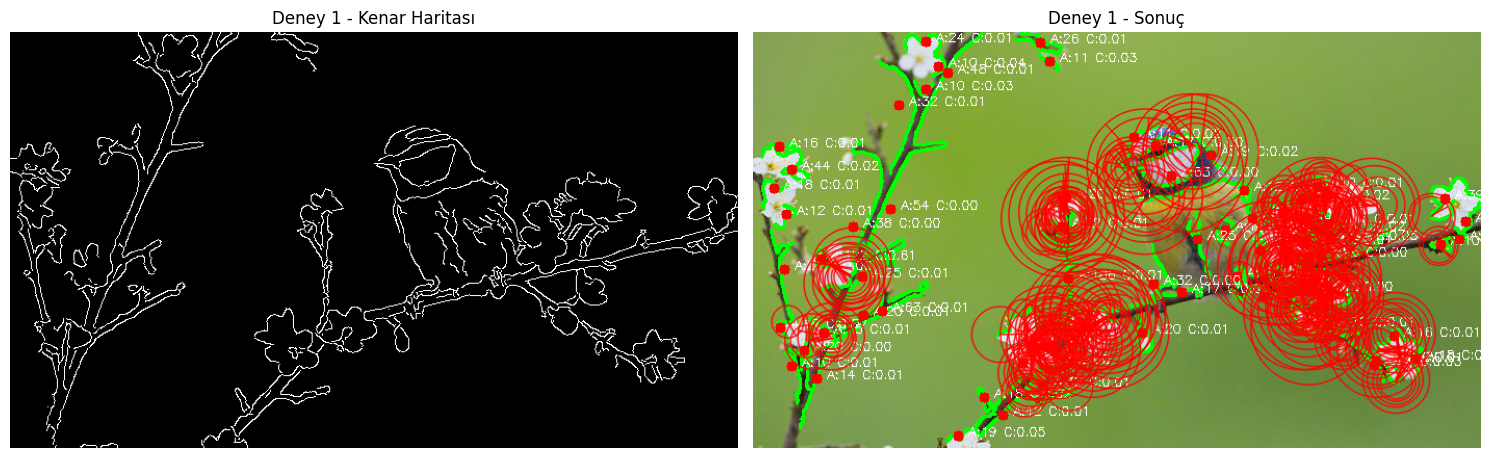

Deney 1 Sonuçları: {'num_contours_total': 224, 'num_contours_valid': 63, 'num_keypoints': 300, 'avg_circularity': np.float64(0.03497890621756542), 'avg_area': np.float64(32.142857142857146)}


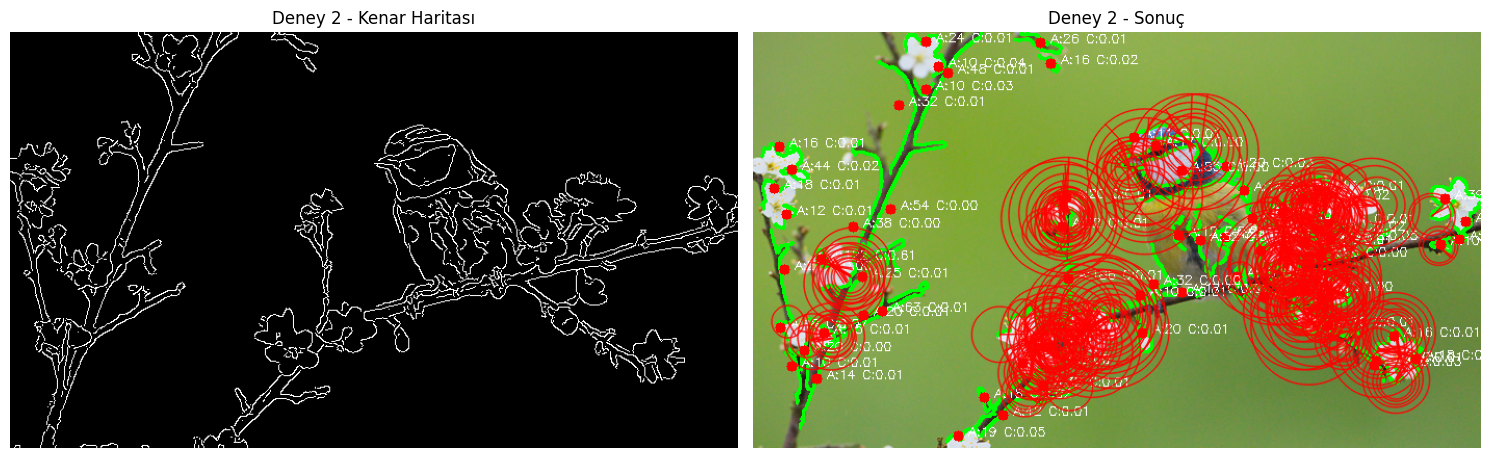

Deney 2 Sonuçları: {'num_contours_total': 413, 'num_contours_valid': 65, 'num_keypoints': 300, 'avg_circularity': np.float64(0.03412858061135753), 'avg_area': np.float64(32.292307692307695)}


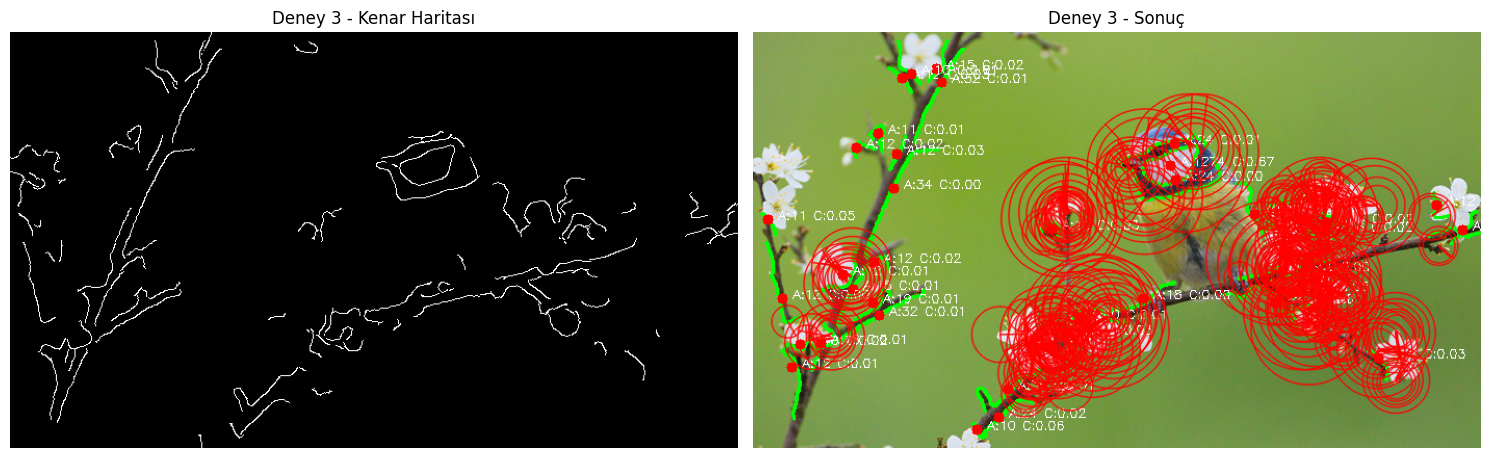

Deney 3 Sonuçları: {'num_contours_total': 98, 'num_contours_valid': 38, 'num_keypoints': 300, 'avg_circularity': np.float64(0.03410348000492045), 'avg_area': np.float64(51.0921052631579)}


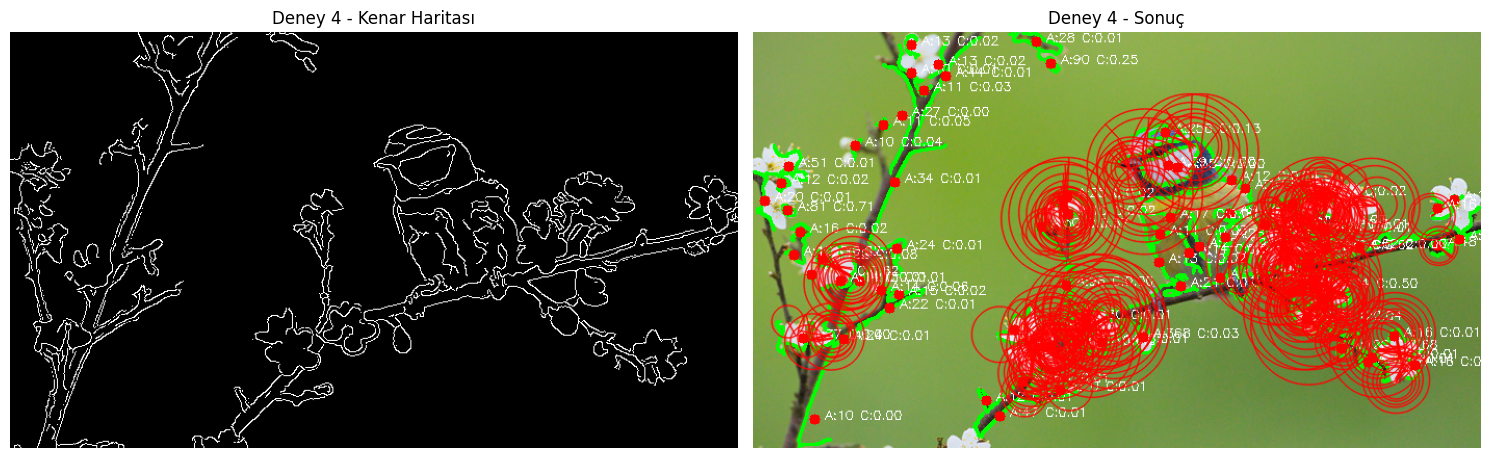

Deney 4 Sonuçları: {'num_contours_total': 357, 'num_contours_valid': 76, 'num_keypoints': 300, 'avg_circularity': np.float64(0.0692448438336551), 'avg_area': np.float64(68.83552631578948)}


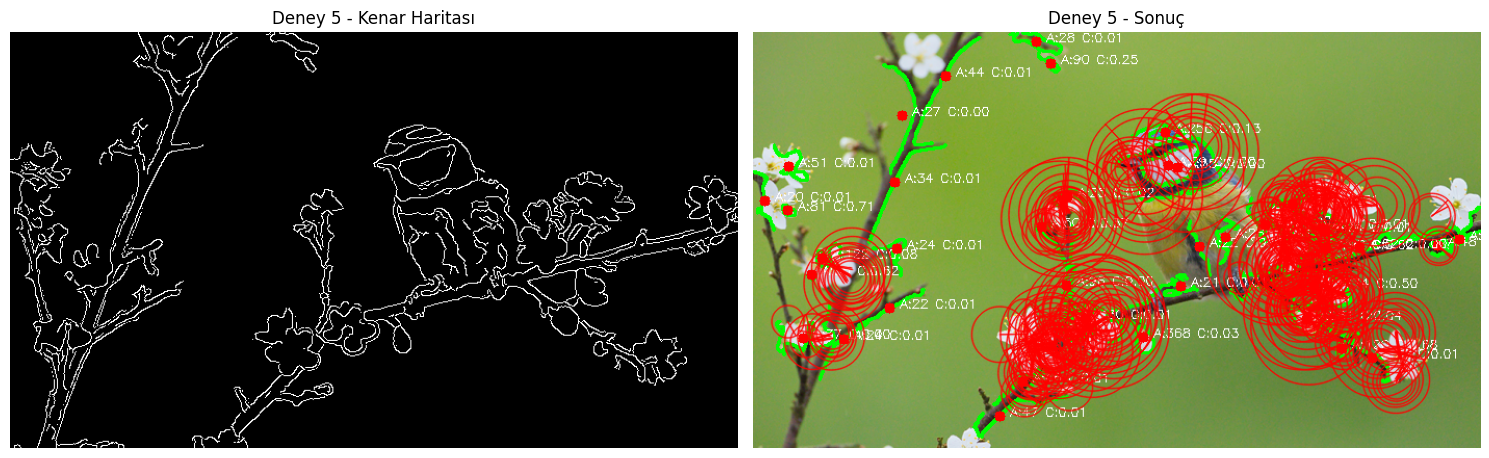

Deney 5 Sonuçları: {'num_contours_total': 357, 'num_contours_valid': 39, 'num_keypoints': 300, 'avg_circularity': np.float64(0.1153046521126466), 'avg_area': np.float64(121.33333333333333)}

KARŞILAŞTIRMA TABLOSU
         Toplam Kontur  Geçerli Kontur  ORB Anahtar Nokta  Ort. Dairesellik  \
Deney 1          224.0            63.0              300.0             0.035   
Deney 2          413.0            65.0              300.0             0.034   
Deney 3           98.0            38.0              300.0             0.034   
Deney 4          357.0            76.0              300.0             0.069   
Deney 5          357.0            39.0              300.0             0.115   

         Ort. Alan  
Deney 1     32.143  
Deney 2     32.292  
Deney 3     51.092  
Deney 4     68.836  
Deney 5    121.333  

✓ Tablo 'deney_sonuclari.csv' olarak kaydedildi


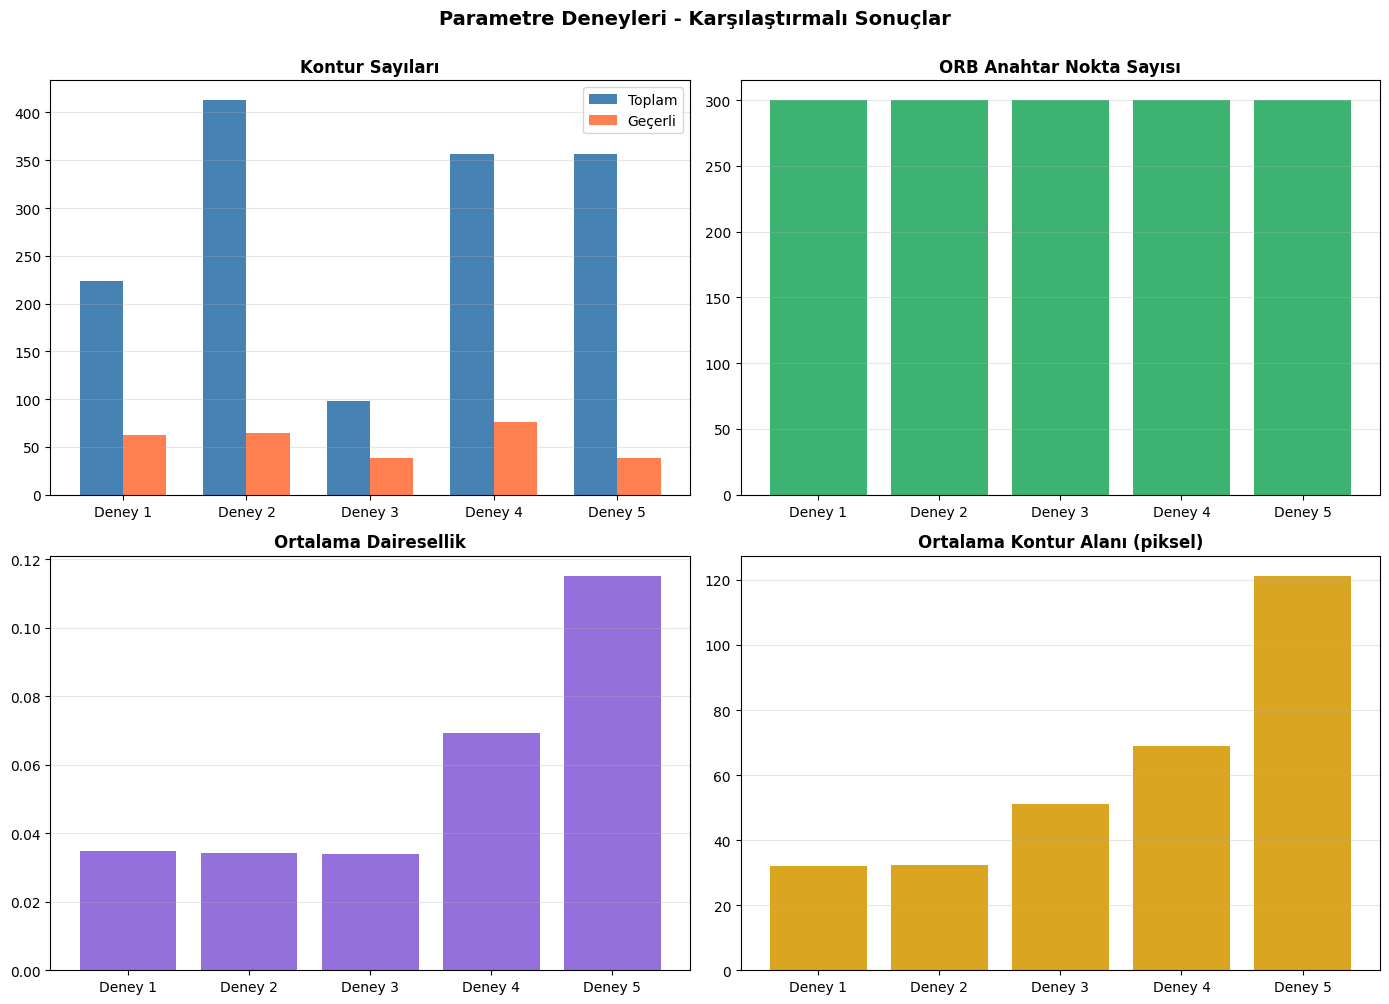


✓ Grafik 'karsilastirma_grafigi.png' olarak kaydedildi


In [17]:
import pandas as pd

all_results = {}

for name, config in configs.items():
    results, img_final, edges = full_pipeline(img_path, config)
    all_results[name] = results

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(edges, cmap='gray')
    axes[0].set_title(f"{name} - Kenar Haritası")
    axes[0].axis('off')
    axes[1].imshow(img_final)
    axes[1].set_title(f"{name} - Sonuç")
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"{name} Sonuçları:", results)

df = pd.DataFrame(all_results).T
df = df[['num_contours_total', 'num_contours_valid', 'num_keypoints',
        'avg_circularity', 'avg_area']]
df.columns = ['Toplam Kontur', 'Geçerli Kontur', 'ORB Anahtar Nokta',
              'Ort. Dairesellik', 'Ort. Alan']

print("\n" + "="*70)
print("KARŞILAŞTIRMA TABLOSU")
print("="*70)
print(df.round(3))

df.to_csv("deney_sonuclari.csv")
print("\n✓ Tablo 'deney_sonuclari.csv' olarak kaydedildi")

# Karşılaştırma grafiği
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
deney_isimleri = list(all_results.keys())

x = np.arange(len(deney_isimleri))
width = 0.35
axes[0,0].bar(x - width/2, df['Toplam Kontur'], width, label='Toplam', color='steelblue')
axes[0,0].bar(x + width/2, df['Geçerli Kontur'], width, label='Geçerli', color='coral')
axes[0,0].set_title('Kontur Sayıları', fontsize=12, fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(deney_isimleri)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].bar(deney_isimleri, df['ORB Anahtar Nokta'], color='mediumseagreen')
axes[0,1].set_title('ORB Anahtar Nokta Sayısı', fontsize=12, fontweight='bold')
axes[0,1].grid(axis='y', alpha=0.3)

axes[1,0].bar(deney_isimleri, df['Ort. Dairesellik'], color='mediumpurple')
axes[1,0].set_title('Ortalama Dairesellik', fontsize=12, fontweight='bold')
axes[1,0].grid(axis='y', alpha=0.3)

axes[1,1].bar(deney_isimleri, df['Ort. Alan'], color='goldenrod')
axes[1,1].set_title('Ortalama Kontur Alanı (piksel)', fontsize=12, fontweight='bold')
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Parametre Deneyleri - Karşılaştırmalı Sonuçlar',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("karsilastirma_grafigi.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Grafik 'karsilastirma_grafigi.png' olarak kaydedildi")
